In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [2]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)

#### Define general measurement params

In [74]:
#measurement parameters
laser_power_voltage = 0.1#podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 2.8448e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = -5
pi_pulse = 48e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 2.87e9
LO_freq_1 = target_freq_1 + 100e6
power_1 = -100
pi_pulse_1 = 72e-9

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'L-Q04-04'
sample = 'FGT'
temperature = '2K'
b_field = '2mT_OOP_ZFC'
contact = '10nm_LO'
extra = ''

#### Load and ready Gradiometry sequence

100%|#####################################################################################| 40/40 [45:36<00:00, 68.41s/it]


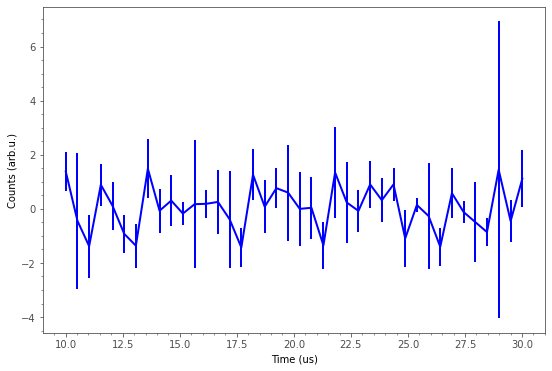

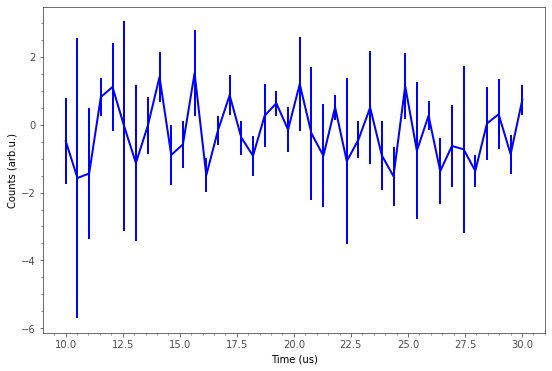

In [3]:
TF_Amp_arr = np.linspace(2.7, 2.7, 1)
TF_Amp = 4
trigger_level0 = 400
trigger_level1 = -200
wait_bw_TF_set = 0

# lift_off_height = 50e-9
lift_off_height_list = [10e-9, 50e-9]#np.linspace(10e-9, 50e-9, 6)
lift_off_check_period = 60*5

tau = 0.5e-6

t0_start = 10e-6
t0_stop = 30e-6
t0_num = 40
max_sweeps = 6e5

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
c_x = np.zeros((len(t0_sweep_init),2))
c_x_alt = np.zeros((len(t0_sweep_init),2))
c_y = np.zeros((len(t0_sweep_init),2))
c_y_alt = np.zeros((len(t0_sweep_init),2))

phase_sweeps = np.zeros_like(t0_sweep_init)


afm_scanner_logic.jupyter_meas_stop = False

setup_autoapproach()
go_into_contact()

meas_dict = {}

for lift_off_height in lift_off_height_list:
#     spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
#     time.sleep(wait_bw_TF_set)

    for i, t_0 in enumerate(tqdm(t0_sweep_init)):
        pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                switch_MW = switch_MW, trigger_type = 'pos_edge_rearm', trigger_level0 = trigger_level0, trigger_level1 = trigger_level1)

        ret = pjl.CPMG1_gradiometry(t_0, tau)
        t0_sweep[i] = ret[5]
#         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    
        #Lift off
        lift_off_start = 0
        if lift_off_height > 0:
            do_lift_off(lift_off_height)
            lift_off_start = time.time()
            
        pjl.start_measurement(measurement_type='CPMG1_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0:
                pulsedmeasurementlogic_AWG.pause_pulsed_measurement()
                go_into_contact()
                do_lift_off(lift_off_height)
                lift_off_start = time.time()
                pulsedmeasurementlogic_AWG.continue_pulsed_measurement()
            
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                c_x[i,:] = (pulsedmasterlogic_AWG.signal_data[1][0], pulsedmasterlogic_AWG.measurement_error[1][0])
                c_y[i,:] = (pulsedmasterlogic_AWG.signal_data[1][1], pulsedmasterlogic_AWG.measurement_error[1][1])
                c_x_alt[i,:] = (pulsedmasterlogic_AWG.signal_data[2][0], pulsedmasterlogic_AWG.measurement_error[2][0])
                c_y_alt[i,:] = (pulsedmasterlogic_AWG.signal_data[2][1], pulsedmasterlogic_AWG.measurement_error[2][1])
                
                phase_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)
                
        go_into_contact()

        if afm_scanner_logic.jupyter_meas_stop:
            break


    meas_dict[lift_off_height] = {"t0_sweep": t0_sweep.copy(), "c_x": c_x.copy(), "c_y": c_y.copy(), "c_x_alt": c_x_alt.copy(), "c_y_alt": c_y_alt.copy(), "phase_sweeps": phase_sweeps.copy(), "lift_off_height":lift_off_height, "tau": tau}
    
    phase = np.arctan((c_y_alt[:,0]-c_y[:,0])/(c_x[:,0]-c_x_alt[:,0]))
    
    #for better reading
    a = c_y_alt[:,0]
    b = c_y[:,0]
    c = c_x[:,0]
    d = c_x_alt[:,0]
    phase_err = np.sqrt((((c-d)/((a-b)**2+(c-d)**2))*c_y_alt[:,1])**2
                        +(((d-c)/((a-b)**2+(c-d)**2))*c_y[:,1])**2
                        +(((b-a)/((a-b)**2+(c-d)**2))*c_x[:,1])**2
                        +(((a-b)/((a-b)**2+(c-d)**2))*c_x_alt[:,1])**2)
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=phase,
                             yerr=phase_err, fmt='b-', label=f'')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')

    plt.show()


    filelabel = tip_name + f"_{lift_off_height}"
    parameters = {'Res_freq':194e3, 'A_exc':TF_Amp, 'Hf_ampl':0.15, "Note": ""}
    data =  {'Time (us), Phase (arb.u.)Phase_err, Elapsed_sweeps': np.array((t0_sweep, phase, phase_err, phase_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'CPMG1_gradiometry'+'_'+tip_name
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)

Pickle load

In [39]:
root = r"G:\Data\Qudi_Data\2024\10\20241031\Lock-In-Tip"
path = root +"\\"+ "2024-10-31_12-09-16_PL_Osc_Exc_sweep_L-R-04-18" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

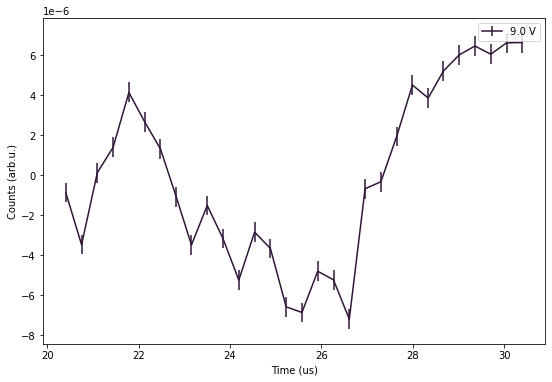

100%|#####################################################################################| 30/30 [03:30<00:00,  7.01s/it]


In [45]:
fig, ax1 = plt.subplots(1,1)

cl = cm.twilight_shifted(list(data.keys()))
for i, key in enumerate(data.keys()):
    t0_sweep = data[key]["t0_sweep"]
    PL_osc = data[key]["PL_Osc"]
    PL_osc_sweeps = data[key]["PL_osc_sweeps"]
    PL_osc_err = data[key]["PL_osc_err"]
    c = PL_osc/PL_osc_sweeps
    c = c - np.mean(c)
#     c /= c.max()
    ax1.errorbar(x=t0_sweep/1e-6, y=c,
                             yerr=PL_osc_err/PL_osc_sweeps,color=cl[i], 
                             label=f'{key} V')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')
plt.legend()
plt.show()